## РК1 по дисциплине "Технологии Машинного Обучения"
**Выполнила:** Канаева Диана Чингисовна

**Группа:** ИУ5-62Б

**Задание (вариант 9):**
Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака.

**Вопросы:**
Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

**Дополнительное задание (группа ИУ5-62Б):** 
Для произвольной колонки данных построить гистограмму.

**Датасет:** Iris Dataset

### Решение
1. Загрузка данных и предварительный анализ

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Установка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')

# Загрузка датасета Iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

# Вывод первых 5 строк
print("Первые 5 строк датасета:")
display(df.head())

# Проверка на пропуски
print("\nПроверка пропущенных значений до их добавления:")
print(df.isnull().sum())

Первые 5 строк датасета:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Проверка пропущенных значений до их добавления:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


2. Добавление искусственных пропусков

In [3]:
# Добавление пропусков в количественный признак (sepal length)
np.random.seed(42)
df.loc[np.random.choice(df.index, size=10), 'sepal length (cm)'] = np.nan

# Добавление пропусков в категориальный признак (species)
df.loc[np.random.choice(df.index, size=5), 'species'] = np.nan

# Проверка пропусков после их добавления
print("Количество пропущенных значений после их добавления:")
print(df.isnull().sum())

Количество пропущенных значений после их добавления:
sepal length (cm)    9
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              5
dtype: int64


3. Построение гистограммы (доп. задание)

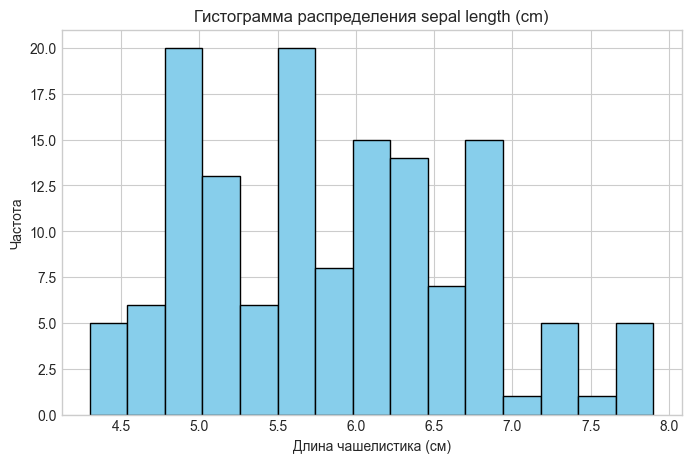

In [4]:
# Гистограмма для 'sepal length (cm)'
plt.figure(figsize=(8, 5))
plt.hist(df['sepal length (cm)'].dropna(), bins=15, color='skyblue', edgecolor='black')
plt.title('Гистограмма распределения sepal length (cm)')
plt.xlabel('Длина чашелистика (см)')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

4. Обработка пропусков

4.1. Обработка количественного признака (sepal length (cm))
Способ: Замена пропусков медианой, так как она устойчива к выбросам.

In [5]:
median_sepal_length = df['sepal length (cm)'].median()
df['sepal length (cm)'].fillna(median_sepal_length, inplace=True)

C:\Users\kanae\AppData\Local\Temp\ipykernel_9620\3421453965.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sepal length (cm)'].fillna(median_sepal_length, inplace=True)


4.2. Обработка категориального признака (species)
Способ: Замена пропусков наиболее частой категорией (модой).

In [6]:
most_frequent_species = df['species'].mode()[0]
df['species'].fillna(most_frequent_species, inplace=True)

C:\Users\kanae\AppData\Local\Temp\ipykernel_9620\2230556819.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['species'].fillna(most_frequent_species, inplace=True)


Проверка обработки пропусков

In [7]:
print("Проверка пропущенных значений после обработки:")
print(df.isnull().sum())

Проверка пропущенных значений после обработки:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


5. Выбор признаков для модели машинного обучения

**Используемые признаки:**

Количественные: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)

Категориальный (целевая переменная): species

**Обоснование:**

Количественные признаки хорошо подходят для алгоритмов классификации (например, RandomForest, LogisticRegression).

Категориальный признак (species) является целевой переменной в задаче классификации.